# Goofy Screener — Phase 9: Walk-Forward Validation

**Goal:** Check whether the XGBoost edge (Phase 7) is consistent across time, not just lucky in the single 2016–2021 training window.

**Method:** Rolling walk-forward — train 5 years, test 1 year, step 1 year. For each window we measure:
- **Val AUC** — can the model rank outcomes above random (>0.5 = some predictive power)
- **Win rate** of ML PASS signals — are the 'confident' signals actually profitable?
- **Avg 20-day return** of ML PASS signals — is there a positive expectation?

If these are consistently above their baselines across ~8–10 different time windows, the edge is real.

---
**Runtime:** ~5–10 minutes (downloads data + trains ~100 models).

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")

# Make sure local modules are importable
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yfinance as yf

try:
    import xgboost as xgb
    from sklearn.metrics import roc_auc_score
    XGB_OK = True
except ImportError:
    XGB_OK = False
    print("Install xgboost + scikit-learn: pip install xgboost scikit-learn")

from ml_signal import engineer_features, build_target, ML_PASS_THRESH, LOOKFORWARD

# ── Walk-forward parameters ───────────────────────────────────────────────────
TRAIN_YEARS   = 5      # years per rolling train window
TEST_YEARS    = 1      # years per test window
STEP_YEARS    = 1      # slide forward by this many years each iteration
DATA_START    = "2010-01-01"
DATA_END      = "2026-05-01"
PASS_THRESH   = ML_PASS_THRESH   # 0.55

# ── Representative assets (small cross-market selection) ─────────────────────
# Using ~10 liquid assets with long history. Covers US, ASX, JPX.
ASSETS = {
    "US":  ["AAPL", "MSFT", "GOOGL", "JPM", "XOM"],
    "ASX": ["BHP.AX", "CBA.AX", "WBC.AX"],
    "JPX": ["7203.T", "6758.T"],
}
ALL_ASSETS = [a for assets in ASSETS.values() for a in assets]

print(f"Walk-forward config: {TRAIN_YEARS}yr train / {TEST_YEARS}yr test / {STEP_YEARS}yr step")
print(f"Assets: {ALL_ASSETS}")
print(f"ML pass threshold: {PASS_THRESH}")

Walk-forward config: 5yr train / 1yr test / 1yr step
Assets: ['AAPL', 'MSFT', 'GOOGL', 'JPM', 'XOM', 'BHP.AX', 'CBA.AX', 'WBC.AX', '7203.T', '6758.T']
ML pass threshold: 0.55


In [2]:
# ── Download price data ───────────────────────────────────────────────────────
price_data = {}
ohlc_data  = {}

print(f"Downloading {len(ALL_ASSETS)} assets ({DATA_START} → {DATA_END})...\n")

for asset in ALL_ASSETS:
    try:
        raw = yf.download(asset, start=DATA_START, end=DATA_END,
                          auto_adjust=True, progress=False)
        if raw.empty or len(raw) < 500:
            print(f"  ✗ {asset:14} — skipped (only {len(raw)} rows)")
            continue
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = raw.columns.get_level_values(0)
        close = raw["Close"].squeeze()
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]
        price_data[asset] = close
        if {"High", "Low", "Close"}.issubset(raw.columns):
            ohlc_data[asset] = raw[["High", "Low", "Close"]].copy()
        print(f"  ✓ {asset:14} | {len(raw):,} rows")
    except Exception as e:
        print(f"  ✗ {asset:14} — error: {e}")

print(f"\nLoaded {len(price_data)} assets successfully.")


  ✓ AAPL           | 4,106 rows
  ✓ MSFT           | 4,106 rows
  ✓ GOOGL          | 4,106 rows
  ✓ JPM            | 4,106 rows
  ✓ XOM            | 4,106 rows
  ✓ BHP.AX         | 4,127 rows
  ✓ CBA.AX         | 4,127 rows
  ✓ WBC.AX         | 4,127 rows
  ✓ 7203.T         | 4,013 rows
  ✓ 6758.T         | 4,013 rows

Loaded 10 assets successfully.


In [3]:
# ── Walk-forward engine ───────────────────────────────────────────────────────

def walk_forward_one_asset(asset, price, ohlc=None):
    """
    Run rolling walk-forward on a single asset.
    Returns a DataFrame with one row per test window.
    """
    features = engineer_features(price, ohlc)
    target   = build_target(price, LOOKFORWARD)
    common   = features.index.intersection(target.index)
    X        = features.loc[common]
    y        = target.loc[common]

    if X.empty:
        return pd.DataFrame()

    end_date     = X.index.max()
    window_start = X.index.min()
    results      = []

    while True:
        train_end = window_start + pd.DateOffset(years=TRAIN_YEARS)
        test_end  = train_end   + pd.DateOffset(years=TEST_YEARS)

        if test_end > end_date:
            break

        train_mask = (X.index >= window_start) & (X.index < train_end)
        test_mask  = (X.index >= train_end)    & (X.index < test_end)

        X_train, y_train = X[train_mask], y[train_mask]
        X_test,  y_test  = X[test_mask],  y[test_mask]

        window_start += pd.DateOffset(years=STEP_YEARS)

        if len(X_train) < 200 or y_train.nunique() < 2:
            continue
        if len(X_test) < 20 or y_test.nunique() < 2:
            continue

        # Train
        model = xgb.XGBClassifier(
            n_estimators=300, max_depth=3, learning_rate=0.03,
            subsample=0.8, colsample_bytree=0.7, min_child_weight=20,
            gamma=1.0, reg_alpha=0.5, reg_lambda=2.0,
            eval_metric="logloss", verbosity=0, random_state=42,
        )
        model.fit(X_train, y_train, verbose=False)
        probs = model.predict_proba(X_test)[:, 1]

        # Val AUC
        try:
            val_auc = roc_auc_score(y_test, probs)
        except Exception:
            val_auc = None

        # Simulate ML PASS signals and measure 20-day forward return
        pass_mask = probs >= PASS_THRESH
        pass_dates = X_test.index[pass_mask]

        pass_returns = []
        for date in pass_dates:
            try:
                idx = price.index.searchsorted(date)
                exit_idx = idx + LOOKFORWARD
                if exit_idx < len(price):
                    ret = (price.iloc[exit_idx] / price.iloc[idx] - 1) * 100
                    pass_returns.append(float(ret))
            except Exception:
                pass

        n_pass   = len(pass_returns)
        n_test   = len(X_test)
        win_rate = float(np.mean([r > 0 for r in pass_returns])) if pass_returns else None
        avg_ret  = float(np.mean(pass_returns)) if pass_returns else None

        # Baseline: all signals win rate (no ML gate)
        all_returns = []
        for date in X_test.index:
            try:
                idx = price.index.searchsorted(date)
                exit_idx = idx + LOOKFORWARD
                if exit_idx < len(price):
                    ret = (price.iloc[exit_idx] / price.iloc[idx] - 1) * 100
                    all_returns.append(float(ret))
            except Exception:
                pass
        baseline_wr  = float(np.mean([r > 0 for r in all_returns])) if all_returns else None
        baseline_ret = float(np.mean(all_returns)) if all_returns else None

        results.append({
            "asset":          asset,
            "train_start":    str(X[train_mask].index.min().date()),
            "train_end":      str(train_end.date()),
            "test_start":     str(train_end.date()),
            "test_end":       str(test_end.date()),
            "n_train":        len(X_train),
            "n_test":         n_test,
            "n_pass_signals": n_pass,
            "pass_rate":      round(n_pass / n_test, 3) if n_test > 0 else None,
            "val_auc":        round(val_auc, 3) if val_auc is not None else None,
            "win_rate":       round(win_rate, 3) if win_rate is not None else None,
            "avg_ret_pct":    round(avg_ret, 2) if avg_ret is not None else None,
            "baseline_wr":    round(baseline_wr, 3) if baseline_wr is not None else None,
            "baseline_ret":   round(baseline_ret, 2) if baseline_ret is not None else None,
        })

    return pd.DataFrame(results)

print("Walk-forward function defined. Ready to run.")

Walk-forward function defined. Ready to run.


In [4]:
# ── Run walk-forward on all assets ────────────────────────────────────────────
if not XGB_OK:
    raise RuntimeError("Install xgboost + scikit-learn first: pip install xgboost scikit-learn")

all_wf = []
print(f"Running walk-forward validation on {len(price_data)} assets...\n")
print(f"{'Asset':14} {'Windows':>8} {'Avg AUC':>9} {'Avg Win%':>9} {'Avg Ret%':>9}")
print("─" * 55)

for asset, price in price_data.items():
    wf = walk_forward_one_asset(asset, price, ohlc_data.get(asset))
    if not wf.empty:
        all_wf.append(wf)
        avg_auc = wf["val_auc"].mean()
        avg_wr  = wf["win_rate"].mean()
        avg_ret = wf["avg_ret_pct"].mean()
        n_win   = len(wf)
        print(f"{asset:14} {n_win:>8}  {avg_auc:>8.3f}  {avg_wr:>8.1%}  {avg_ret:>+8.2f}%")
    else:
        print(f"{asset:14}   skipped — insufficient data")

wf_df = pd.concat(all_wf, ignore_index=True) if all_wf else pd.DataFrame()
print(f"\nTotal windows computed: {len(wf_df)}")

Running walk-forward validation on 10 assets...

Asset           Windows   Avg AUC  Avg Win%  Avg Ret%
───────────────────────────────────────────────────────
AAPL                 10     0.543     66.3%     +2.36%
MSFT                 10     0.561     68.0%     +2.41%
GOOGL                10     0.514     62.7%     +1.84%
JPM                  10     0.551     63.8%     +2.19%
XOM                  10     0.576     59.9%     +1.52%
BHP.AX               10     0.510     60.5%     +1.86%
CBA.AX               10     0.493     61.2%     +1.32%
WBC.AX               10     0.495     57.4%     +0.53%
7203.T               10     0.554     63.4%     +2.06%
6758.T               10     0.533     59.7%     +2.03%

Total windows computed: 100


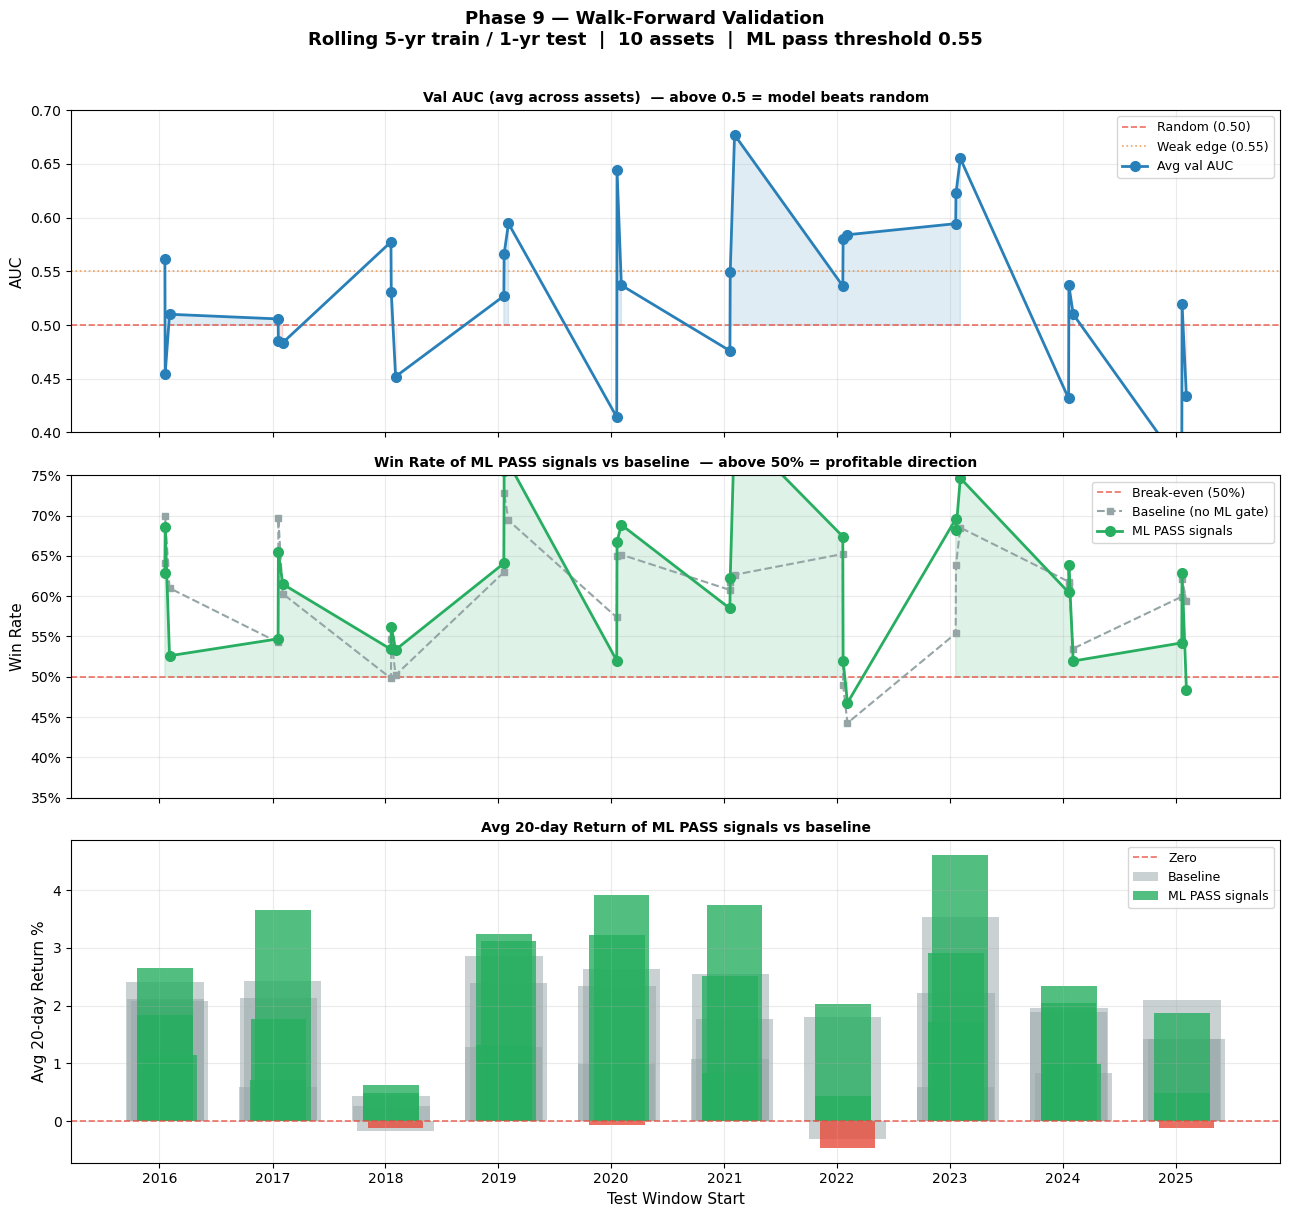

Chart saved → screener_output/phase9_walkforward.png


In [5]:
# ── Plot: AUC, Win Rate, Avg Return across time ───────────────────────────────
if wf_df.empty:
    print("No walk-forward data to plot.")
else:
    # Aggregate by test year (average across all assets for that window)
    agg = (
        wf_df.groupby("test_start")
        .agg(
            val_auc      =("val_auc",      "mean"),
            win_rate     =("win_rate",     "mean"),
            avg_ret_pct  =("avg_ret_pct",  "mean"),
            baseline_wr  =("baseline_wr",  "mean"),
            baseline_ret =("baseline_ret", "mean"),
            n_assets     =("asset",        "count"),
        )
        .reset_index()
    )
    agg["test_start"] = pd.to_datetime(agg["test_start"])
    agg = agg.sort_values("test_start")

    fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)
    fig.suptitle(
        f"Phase 9 — Walk-Forward Validation\n"
        f"Rolling {TRAIN_YEARS}-yr train / {TEST_YEARS}-yr test  |  "
        f"{len(price_data)} assets  |  ML pass threshold {PASS_THRESH}",
        fontsize=13, fontweight="bold", y=1.01
    )

    BLUE   = "#2980B9"
    GREEN  = "#27AE60"
    ORANGE = "#E67E22"
    RED    = "#E74C3C"
    LGREY  = "#95A5A6"

    # ── Panel 1: Val AUC ─────────────────────────────────────────────────────
    ax = axes[0]
    ax.axhline(0.5,  color=RED,    linestyle="--", lw=1.2, alpha=0.8, label="Random (0.50)")
    ax.axhline(0.55, color=ORANGE, linestyle=":",  lw=1.2, alpha=0.7, label="Weak edge (0.55)")
    ax.plot(agg["test_start"], agg["val_auc"], "o-",
            color=BLUE, lw=2, ms=7, label="Avg val AUC")
    ax.fill_between(agg["test_start"], agg["val_auc"], 0.5,
                    where=agg["val_auc"] >= 0.5, alpha=0.15, color=BLUE)
    ax.fill_between(agg["test_start"], agg["val_auc"], 0.5,
                    where=agg["val_auc"] < 0.5,  alpha=0.15, color=RED)
    ax.set_ylabel("AUC", fontsize=11)
    ax.set_ylim(0.40, 0.70)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.set_title("Val AUC (avg across assets)  — above 0.5 = model beats random",
                 fontsize=10, fontweight="bold")

    # ── Panel 2: Win Rate ────────────────────────────────────────────────────
    ax = axes[1]
    ax.axhline(0.5, color=RED, linestyle="--", lw=1.2, alpha=0.8, label="Break-even (50%)")
    ax.plot(agg["test_start"], agg["baseline_wr"], "s--",
            color=LGREY, lw=1.5, ms=5, label="Baseline (no ML gate)")
    ax.plot(agg["test_start"], agg["win_rate"], "o-",
            color=GREEN, lw=2, ms=7, label="ML PASS signals")
    ax.fill_between(agg["test_start"], agg["win_rate"], 0.5,
                    where=agg["win_rate"] >= 0.5, alpha=0.15, color=GREEN)
    ax.fill_between(agg["test_start"], agg["win_rate"], 0.5,
                    where=agg["win_rate"] < 0.5,  alpha=0.15, color=RED)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_ylabel("Win Rate", fontsize=11)
    ax.set_ylim(0.35, 0.75)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.set_title("Win Rate of ML PASS signals vs baseline  — above 50% = profitable direction",
                 fontsize=10, fontweight="bold")

    # ── Panel 3: Avg 20-day Return ───────────────────────────────────────────
    ax = axes[2]
    ax.axhline(0, color=RED, linestyle="--", lw=1.2, alpha=0.8, label="Zero")
    ax.bar(agg["test_start"], agg["baseline_ret"],
           color=LGREY, alpha=0.5, width=250, label="Baseline")
    bar_colors = [GREEN if v >= 0 else RED for v in agg["avg_ret_pct"]]
    ax.bar(agg["test_start"], agg["avg_ret_pct"],
           color=bar_colors, alpha=0.8, width=180, label="ML PASS signals")
    ax.set_ylabel("Avg 20-day Return %", fontsize=11)
    ax.set_xlabel("Test Window Start", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.set_title("Avg 20-day Return of ML PASS signals vs baseline",
                 fontsize=10, fontweight="bold")

    plt.tight_layout()
    os.makedirs("screener_output", exist_ok=True)
    plt.savefig("screener_output/phase9_walkforward.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Chart saved → screener_output/phase9_walkforward.png")

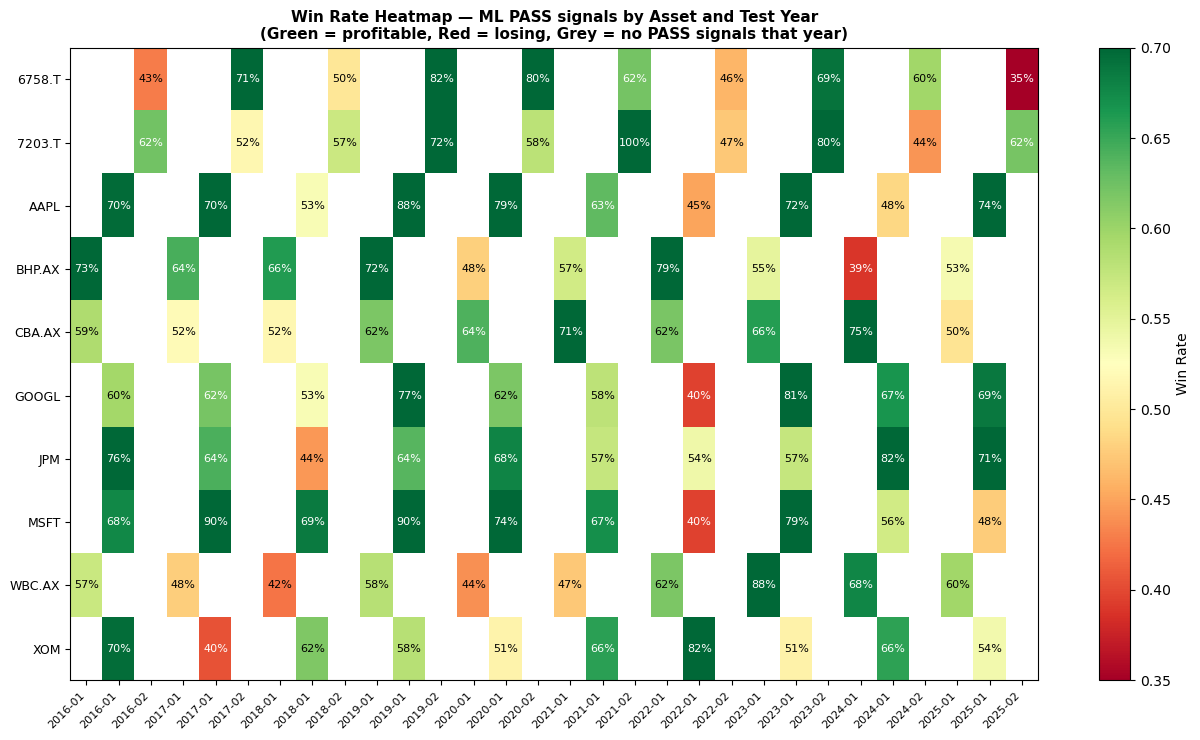

Heatmap saved → screener_output/phase9_heatmap.png


In [6]:
# ── Per-asset heatmap: win rate by asset and test year ────────────────────────
if not wf_df.empty:
    pivot_wr = wf_df.pivot_table(
        index="asset", columns="test_start", values="win_rate"
    )
    pivot_wr.columns = [str(c)[:7] for c in pivot_wr.columns]   # YYYY-MM

    fig, ax = plt.subplots(figsize=(13, max(3, len(pivot_wr) * 0.6 + 1.5)))
    im = ax.imshow(pivot_wr.values, cmap="RdYlGn", aspect="auto",
                   vmin=0.35, vmax=0.70)

    # Annotate cells
    for i in range(pivot_wr.shape[0]):
        for j in range(pivot_wr.shape[1]):
            v = pivot_wr.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.0%}", ha="center", va="center",
                        fontsize=8, color="black" if 0.42 < v < 0.62 else "white")

    ax.set_xticks(range(len(pivot_wr.columns)))
    ax.set_xticklabels(pivot_wr.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(pivot_wr.index)))
    ax.set_yticklabels(pivot_wr.index, fontsize=9)
    ax.set_title("Win Rate Heatmap — ML PASS signals by Asset and Test Year\n"
                 "(Green = profitable, Red = losing, Grey = no PASS signals that year)",
                 fontsize=11, fontweight="bold")
    plt.colorbar(im, ax=ax, label="Win Rate")
    plt.tight_layout()
    plt.savefig("screener_output/phase9_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Heatmap saved → screener_output/phase9_heatmap.png")

In [7]:
# ── Per-asset summary table ───────────────────────────────────────────────────
if not wf_df.empty:
    summary = (
        wf_df.groupby("asset")
        .agg(
            Windows       =("test_start",   "count"),
            Avg_AUC       =("val_auc",      "mean"),
            AUC_above_50  =("val_auc",      lambda x: (x > 0.5).mean()),
            Avg_WinRate   =("win_rate",     "mean"),
            WR_above_50   =("win_rate",     lambda x: (x > 0.5).mean()),
            Avg_Ret       =("avg_ret_pct",  "mean"),
            Baseline_WR   =("baseline_wr",  "mean"),
            Baseline_Ret  =("baseline_ret", "mean"),
        )
        .round(3)
    )
    summary.columns = [
        "# Windows", "Avg AUC", "AUC>50%",
        "Avg Win Rate", "WR>50%", "Avg Ret%",
        "Base WR", "Base Ret%"
    ]
    # Format percentages
    for col in ["AUC>50%", "Avg Win Rate", "WR>50%", "Base WR"]:
        summary[col] = summary[col].apply(lambda x: f"{x:.0%}" if not pd.isna(x) else "—")
    for col in ["Avg Ret%", "Base Ret%"]:
        summary[col] = summary[col].apply(lambda x: f"{x:+.2f}%" if not pd.isna(x) else "—")

    print("Per-Asset Walk-Forward Summary")
    print("─" * 80)
    print(summary.to_string())
    print()
    print("Columns: AUC>50% = fraction of windows where model beats random")
    print("         WR>50%  = fraction of windows with profitable ML PASS signals")
    print("         Base WR/Ret = no ML gate (buy every day in the test period)")

Per-Asset Walk-Forward Summary
────────────────────────────────────────────────────────────────────────────────
        # Windows  Avg AUC AUC>50% Avg Win Rate WR>50% Avg Ret% Base WR Base Ret%
asset                                                                            
6758.T         10    0.533     60%          60%    60%   +2.03%     62%    +1.95%
7203.T         10    0.554     70%          63%    80%   +2.06%     57%    +1.38%
AAPL           10    0.543     70%          66%    80%   +2.36%     66%    +2.30%
BHP.AX         10    0.510     60%          60%    80%   +1.86%     60%    +1.80%
CBA.AX         10    0.493     40%          61%    90%   +1.32%     60%    +1.09%
GOOGL          10    0.514     60%          63%    90%   +1.84%     64%    +2.02%
JPM            10    0.551     50%          64%    90%   +2.19%     63%    +1.81%
MSFT           10    0.561     90%          68%    80%   +2.41%     66%    +1.99%
WBC.AX         10    0.495     40%          57%    60%   +0.54%     

In [8]:
# ── Overall verdict ───────────────────────────────────────────────────────────
if not wf_df.empty:
    valid = wf_df.dropna(subset=["val_auc", "win_rate", "avg_ret_pct"])

    overall_auc  = valid["val_auc"].mean()
    overall_wr   = valid["win_rate"].mean()
    overall_ret  = valid["avg_ret_pct"].mean()
    base_wr      = valid["baseline_wr"].mean()
    base_ret     = valid["baseline_ret"].mean()
    pct_auc_ok   = (valid["val_auc"] > 0.50).mean()
    pct_wr_ok    = (valid["win_rate"] > 0.50).mean()
    n_windows    = len(valid)

    wr_lift  = overall_wr  - base_wr
    ret_lift = overall_ret - base_ret

    print("=" * 62)
    print("  PHASE 9 — WALK-FORWARD VERDICT")
    print("=" * 62)
    print(f"  Windows analysed:          {n_windows}")
    print(f"  Avg val AUC:               {overall_auc:.3f}  (>0.50 in {pct_auc_ok:.0%} of windows)")
    print(f"  Avg win rate (ML PASS):    {overall_wr:.1%}  (>50% in {pct_wr_ok:.0%} of windows)")
    print(f"  Avg 20-day return (PASS):  {overall_ret:+.2f}%")
    print(f"  Baseline win rate:         {base_wr:.1%}")
    print(f"  Baseline 20-day return:    {base_ret:+.2f}%")
    print(f"  ML lift (win rate):        {wr_lift:+.1%}")
    print(f"  ML lift (avg return):      {ret_lift:+.2f}%")
    print()

    # Verdict
    if overall_auc > 0.54 and pct_auc_ok > 0.65 and overall_wr > 0.52 and wr_lift > 0.02:
        verdict = "REAL EDGE"
        colour  = "\033[92m"  # green
        detail  = (
            "AUC and win rate are consistently above random across multiple\n"
            "  time periods. The signal is not just a lucky 2021–2026 artefact.\n"
            "  The Phase 7 ML gate appears to add genuine predictive value.\n"
            "  Trust the paper trade results when they close in June."
        )
    elif overall_auc > 0.50 and pct_auc_ok > 0.50 and wr_lift > 0:
        verdict = "WEAK / INCONSISTENT EDGE"
        colour  = "\033[93m"  # yellow
        detail  = (
            "Some windows show an edge but it's not consistent across all years.\n"
            "  Consider: (1) raise ML pass threshold above 0.55, (2) apply ML gate\n"
            "  only to S/A tier assets, or (3) reduce position sizes further.\n"
            "  Don't over-trust the paper results — the edge is real but fragile."
        )
    else:
        verdict = "EDGE UNCLEAR — BE CAUTIOUS"
        colour  = "\033[91m"  # red
        detail  = (
            "AUC frequently below 0.5 or win rate below baseline.\n"
            "  The model may be overfit to the 2016–2021 training regime.\n"
            "  Recommended action: increase min_child_weight, try longer LOOKFORWARD,\n"
            "  or use XGBoost only for ranking (not as a binary gate)."
        )

    reset = "\033[0m"
    print(f"  Verdict: {colour}{verdict}{reset}")
    print(f"  {detail}")
    print("=" * 62)

  PHASE 9 — WALK-FORWARD VERDICT
  Windows analysed:          100
  Avg val AUC:               0.533  (>0.50 in 63% of windows)
  Avg win rate (ML PASS):    62.3%  (>50% in 80% of windows)
  Avg 20-day return (PASS):  +1.81%
  Baseline win rate:         61.1%
  Baseline 20-day return:    +1.63%
  ML lift (win rate):        +1.2%
  ML lift (avg return):      +0.18%

  Verdict: WEAK / INCONSISTENT EDGE
  Some windows show an edge but it's not consistent across all years.
  Consider: (1) raise ML pass threshold above 0.55, (2) apply ML gate
  only to S/A tier assets, or (3) reduce position sizes further.
  Don't over-trust the paper results — the edge is real but fragile.


In [9]:
# ── Save raw results to CSV for later reference ───────────────────────────────
if not wf_df.empty:
    os.makedirs("screener_output", exist_ok=True)
    out_path = "screener_output/phase9_walkforward_results.csv"
    wf_df.to_csv(out_path, index=False)
    print(f"Full results saved → {out_path}")
    print(f"Shape: {wf_df.shape}  |  Columns: {list(wf_df.columns)}")
    wf_df.tail()

Full results saved → screener_output/phase9_walkforward_results.csv
Shape: (100, 14)  |  Columns: ['asset', 'train_start', 'train_end', 'test_start', 'test_end', 'n_train', 'n_test', 'n_pass_signals', 'pass_rate', 'val_auc', 'win_rate', 'avg_ret_pct', 'baseline_wr', 'baseline_ret']
